In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
cols_to_keep = [
    'year',
    'Rndrng_Prvdr_Type',
    'Rndrng_Prvdr_State_Abrvtn',
    'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
    'Tot_HCPCS_Cds',
    'Tot_Benes',
    'Tot_Srvcs',
    'Tot_Sbmtd_Chrg',
    'Tot_Mdcr_Alowd_Amt',
    'Tot_Mdcr_Pymt_Amt',
    'Bene_Avg_Age',
    'Bene_Avg_Risk_Scre'
]

df= pd.read_csv("Dataset_only_related_cols.csv", usecols=cols_to_keep)

In [3]:
df_sample = (
    df.groupby("year", group_keys=False)
      .apply(lambda x: x.sample(n=min(len(x), 20000), random_state=42).assign(year=x.name))
      .reset_index(drop=True)
)

In [9]:
df_sample['Tot_Mdcr_Pymt_Amt_log'] = np.log1p(df_sample['Tot_Mdcr_Pymt_Amt'])
df_sample['log_Tot_Benes'] = np.log1p(df_sample['Tot_Benes'])
df_sample['log_Tot_Srvcs'] = np.log1p(df_sample['Tot_Srvcs'])
df_sample['log_Tot_Sbmtd_Chrg'] = np.log1p(df_sample['Tot_Sbmtd_Chrg'])
df_sample['log_Tot_Mdcr_Alowd_Amt'] = np.log1p(df_sample['Tot_Mdcr_Alowd_Amt'])

df_sample['srvcs_per_bene'] = df_sample['Tot_Srvcs'] / (df_sample['Tot_Benes'] + 1)
df_sample['allowed_per_service'] = df_sample['Tot_Mdcr_Alowd_Amt'] / (df_sample['Tot_Srvcs'] + 1)
df_sample['submitted_per_service'] = df_sample['Tot_Sbmtd_Chrg'] / (df_sample['Tot_Srvcs'] + 1)

In [10]:
print(df_sample[[
    'log_Tot_Benes',
    'log_Tot_Srvcs',
    'log_Tot_Sbmtd_Chrg',
    'log_Tot_Mdcr_Alowd_Amt',
    'srvcs_per_bene',
    'allowed_per_service',
    'submitted_per_service'
]].head())

   log_Tot_Benes  log_Tot_Srvcs  log_Tot_Sbmtd_Chrg  log_Tot_Mdcr_Alowd_Amt  \
0       4.094345       6.642487            8.678632                8.638687   
1       4.330733       5.068904           10.750985                9.774568   
2       4.174387       5.204007           10.679619                9.696335   
3       3.258097       4.605170            9.626152                9.204956   
4       6.927558       8.097122           13.354586               12.486372   

   srvcs_per_bene  allowed_per_service  submitted_per_service  
0       12.766667             7.359726               7.659713  
1        2.078947           110.565409             293.553459  
2        2.784615            89.323681             238.791209  
3        3.807692            99.453000             151.550000  
4        3.219608            80.579702             191.993607  


In [11]:
df_sample.head()

,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,year,Tot_Mdcr_Pymt_Amt_log,log_Tot_Benes,log_Tot_Srvcs,log_Tot_Sbmtd_Chrg,log_Tot_Mdcr_Alowd_Amt,srvcs_per_bene,allowed_per_service,submitted_per_service
0,OH,VisionHearing,Y,6,59,766.0,5875.0,5644.91,3325.27,73,0.7680,2013,8.109607,4.094345,6.642487,8.678632,8.638687,12.766667,7.359726,7.659713
1,NJ,MedicalSpecialtyOther,Y,11,75,158.0,46675.0,17579.90,13911.10,67,1.3046,2013,9.540514,4.330733,5.068904,10.750985,9.774568,2.078947,110.565409,293.553459
2,NM,PrimaryCare,Y,12,64,181.0,43460.0,16256.91,12925.64,65,2.1357,2013,9.467046,4.174387,5.204007,10.679619,9.696335,2.784615,89.323681,238.791209
3,WA,PrimaryCare,Y,7,25,99.0,15155.0,9945.30,7286.85,75,0.8652,2013,8.893964,3.258097,4.605170,9.626152,9.204956,3.807692,99.453000,151.550000
4,MI,Cardiology,Y,70,1019,3284.0,630699.0,264704.32,203962.39,72,1.5869,2013,12.225696,6.927558,8.097122,13.354586,12.486372,3.219608,80.579702,191.993607


In [12]:
string_cols = df_sample.select_dtypes(include=['object']).columns.tolist()
print("String columns:", string_cols)

# one-hot encode them
df_encoded = pd.get_dummies(df_sample, columns=string_cols, drop_first=False)

print(df_encoded.shape)
print(df_encoded.head())

String columns: ['Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind']
(220000, 97)
   Tot_HCPCS_Cds  Tot_Benes  Tot_Srvcs  Tot_Sbmtd_Chrg  Tot_Mdcr_Alowd_Amt  \
0              6         59      766.0          5875.0             5644.91   
1             11         75      158.0         46675.0            17579.90   
2             12         64      181.0         43460.0            16256.91   
3              7         25       99.0         15155.0             9945.30   
4             70       1019     3284.0        630699.0           264704.32   

   Tot_Mdcr_Pymt_Amt  Bene_Avg_Age  Bene_Avg_Risk_Scre  year  \
0            3325.27            73              0.7680  2013   
1           13911.10            67              1.3046  2013   
2           12925.64            65              2.1357  2013   
3            7286.85            75              0.8652  2013   
4          203962.39            72              1.5869  2013   

   Tot_Mdcr_Pymt_Amt_log  ...  Rn

/tmp/ipykernel_72947/397641307.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_sample.select_dtypes(include=['object']).columns.tolist()


In [13]:
train_df = df_encoded[df_encoded['year'].between(2013, 2020)].copy()
val_df   = df_encoded[df_encoded['year'] == 2021].copy()
test_df  = df_encoded[df_encoded['year'].between(2022, 2023)].copy()

target = 'Tot_Mdcr_Pymt_Amt_log'

In [17]:
# drop leakage columns
drop_cols = [target, 'Tot_Mdcr_Pymt_Amt',
             'Tot_Mdcr_Alowd_Amt', 
             'log_Tot_Mdcr_Alowd_Amt',
             'allowed_per_service',
             'Tot_Sbmtd_Chrg',
             'log_Tot_Sbmtd_Chrg',
             'submitted_per_service']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

print("Train:", X_train.shape, y_train.shape)
print("val :", X_val.shape, y_val.shape)

Train: (160000, 89) (160000,)
val : (20000, 89) (20000,)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred_log = lr.predict(X_val)

In [20]:
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
mae_log = mean_absolute_error(y_val, y_pred_log)
r2_log = r2_score(y_val, y_pred_log)

print("RMSE (log scale):", rmse_log)
print("MAE  (log scale):", mae_log)
print("R^2  (log scale):", r2_log)

RMSE (log scale): 0.5080637940504565
MAE  (log scale): 0.3617261988506271
R^2  (log scale): 0.8832384060627274


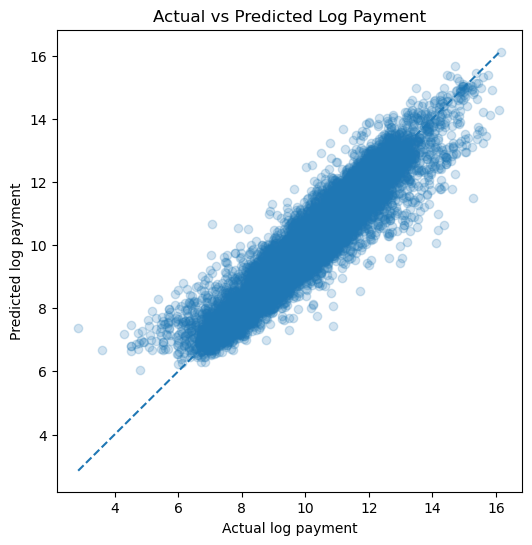

In [21]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_log, alpha=0.2)
plt.xlabel("Actual log payment")
plt.ylabel("Predicted log payment")
plt.title("Actual vs Predicted Log Payment")

# ideal line
mn = min(y_val.min(), y_pred_log.min())
mx = max(y_val.max(), y_pred_log.max())
plt.plot([mn, mx], [mn, mx], linestyle='--')

plt.show()

In [22]:
y_pred_log = lr.predict(X_test)

In [23]:
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

print("RMSE (log scale):", rmse_log)
print("MAE  (log scale):", mae_log)
print("R^2  (log scale):", r2_log)

RMSE (log scale): 0.5169744574191943
MAE  (log scale): 0.3581644545442783
R^2  (log scale): 0.8801786545395085


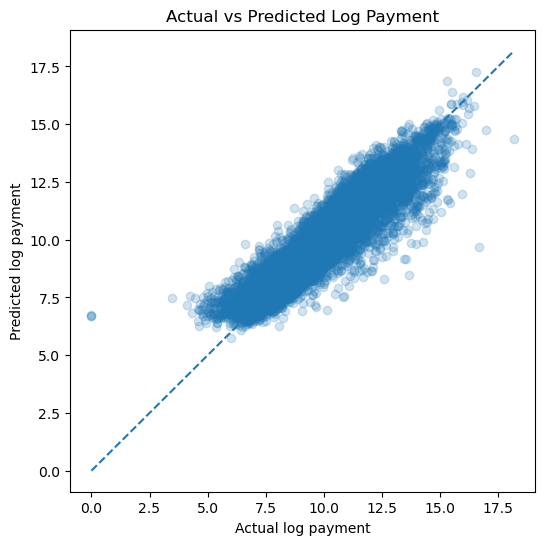

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_log, alpha=0.2)
plt.xlabel("Actual log payment")
plt.ylabel("Predicted log payment")
plt.title("Actual vs Predicted Log Payment")

# ideal line
mn = min(y_test.min(), y_pred_log.min())
mx = max(y_test.max(), y_pred_log.max())
plt.plot([mn, mx], [mn, mx], linestyle='--')

plt.show()

In [26]:
# keep predictions with year
results = test_df[['year']].copy()
results['actual_log_payment'] = y_test.values
results['predicted_log_payment'] = y_pred_log
results['residual'] = results['actual_log_payment'] - results['predicted_log_payment']

print(results.head())

        year  actual_log_payment  predicted_log_payment  residual
180000  2022           12.012909              11.265085  0.747824
180001  2022            9.939884              10.074516 -0.134632
180002  2022            9.640177              10.077650 -0.437472
180003  2022            9.989841              10.111232 -0.121391
180004  2022            9.984822               9.881288  0.103535


In [27]:
yearly_metrics = []

for yr, grp in results.groupby('year'):
    rmse = np.sqrt(mean_squared_error(grp['actual_log_payment'], grp['predicted_log_payment']))
    mae = mean_absolute_error(grp['actual_log_payment'], grp['predicted_log_payment'])
    r2 = r2_score(grp['actual_log_payment'], grp['predicted_log_payment'])
    
    yearly_metrics.append({
        'year': yr,
        'RMSE_log': rmse,
        'MAE_log': mae,
        'R2_log': r2,
        'n_rows': len(grp)
    })

yearly_metrics_df = pd.DataFrame(yearly_metrics).sort_values('year')
print(yearly_metrics_df)

   year  RMSE_log   MAE_log    R2_log  n_rows
0  2022  0.513864  0.358867  0.882123   20000
1  2023  0.520066  0.357462  0.878216   20000


In [28]:
results['actual_payment'] = np.expm1(results['actual_log_payment'])
results['predicted_payment'] = np.expm1(results['predicted_log_payment'])

print(results[['year', 'actual_payment', 'predicted_payment']].head())

        year  actual_payment  predicted_payment
180000  2022       164868.41       78047.467476
180001  2022        20740.33       23729.485346
180002  2022        15369.07       23803.972419
180003  2022        21802.83       24616.962722
180004  2022        21693.68       19559.891152
